In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
from shapely.geometry import Point
import geopandas as gpd
import contextily as ctx

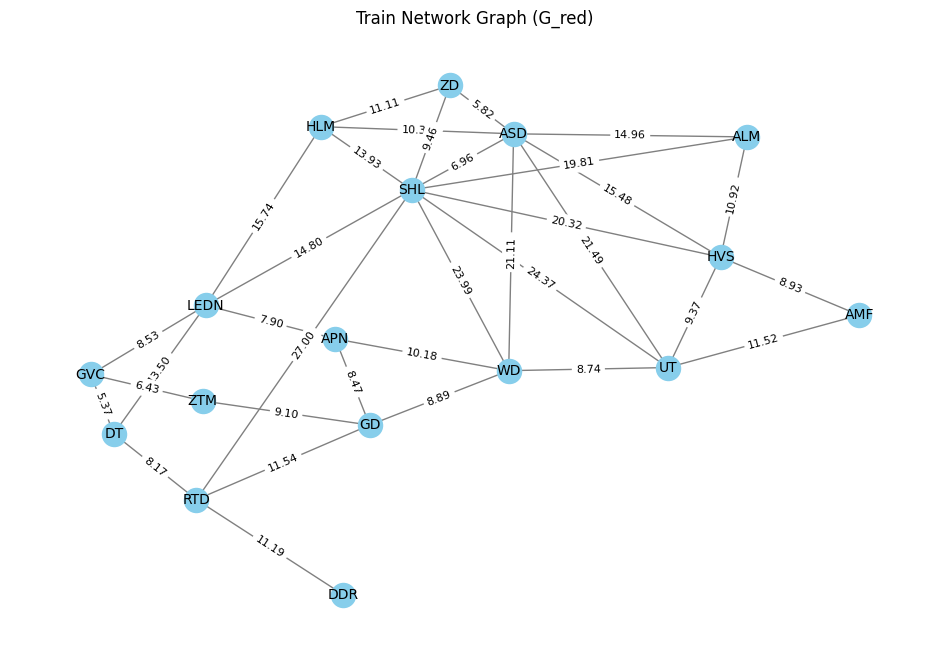

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load CSVs
nodes_df = pd.read_csv("network_nodes_train.csv")  # columns: name, station, lat, lng
edges_df = pd.read_csv("network_edges_train.csv")  # columns: from, to, travel_time

# Create undirected graph
G_red = nx.Graph()

# Add nodes with attributes
for _, row in nodes_df.iterrows():
    G_red.add_node(row['name'], lat=row['lat'], lon=row['lng'], station=row['station'])

# Add edges from CSV
for _, row in edges_df.iterrows():
    G_red.add_edge(row['from'], row['to'], weight=row['travel_time'])

# Positions based on lon/x and lat/y
pos = {node: (data['lon'], data['lat']) for node, data in G_red.nodes(data=True)}

# Plot the graph
plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes(G_red, pos, node_size=300, node_color='skyblue')
nx.draw_networkx_edges(G_red, pos, edge_color='gray')  # undirected, no arrows
nx.draw_networkx_labels(G_red, pos, font_size=10, font_color='black')

# Edge labels = travel_time rounded to 2 decimals
edge_labels = { (u,v): f"{d['weight']:.2f}" for u,v,d in G_red.edges(data=True) }
nx.draw_networkx_edge_labels(G_red, pos, edge_labels=edge_labels, font_size=8)

plt.title("Train Network Graph (G_red)")
plt.axis('off')
plt.show()

In [3]:
# =============================================================
# Network Metrics Table
# Computed on G_red (reduced graph of red/key-city nodes)
# Dyadicity computed on the full graph G (red vs blue nodes)
# =============================================================

# ------------------------------------------------------------------
# 1. Degree Centrality of Nodes (DCS)
#    Fraction of other nodes each node is connected to.
# ------------------------------------------------------------------
dcs = nx.degree_centrality(G_red)

# ------------------------------------------------------------------
# 2. Closeness Centrality of Nodes (CCN)
#    How close a node is to all others (uses edge weights as distances).
#    A larger weight means a longer path, so shorter distances => higher
#    centrality is preserved by passing distance='weight'.
# ------------------------------------------------------------------
ccn = nx.closeness_centrality(G_red, distance='weight')

# ------------------------------------------------------------------
# 3. Betweenness Centrality of Nodes (BCN)
#    Fraction of all-pairs shortest paths that pass through each node.
#    Normalised to [0, 1].
# ------------------------------------------------------------------
bcn = nx.betweenness_centrality(G_red, weight='weight', normalized=True)

# ------------------------------------------------------------------
# 4. Local Clustering Coefficient of Nodes (LCN)
#    Fraction of a node's neighbours that are also connected to each other.
#    Weighted variant accounts for edge strengths.
# ------------------------------------------------------------------
lcn = nx.clustering(G_red, weight='weight')

# 5. Weighted Degree (Strength)
# Sum of edge weights — but since weight = distance, invert it so 
# shorter/more connections = higher score
strength = {
    node: sum(1 / d['weight'] for _, _, d in G_red.edges(node, data=True))
    for node in G_red.nodes()
}

# 6. Eigenvector Centrality (weighted)
# Being connected to well-connected nodes — important for hub resilience
eigenvector = nx.eigenvector_centrality(G_red, weight='weight')

# 7. Average Weighted Shortest Path to all other nodes (Accessibility)
# Lower = more centrally located geographically in the network
accessibility = {}
for node in G_red.nodes():
    paths = nx.single_source_dijkstra_path_length(G_red, node, weight='weight')
    other_paths = [v for k, v in paths.items() if k != node]
    accessibility[node] = np.mean(other_paths) if other_paths else float('inf')

# ------------------------------------------------------------------
# Build and display the combined metrics table
# ------------------------------------------------------------------
metrics_df = pd.DataFrame({
    'Node': list(G_red.nodes()),
    'Station': [G_red.nodes[n]['station'] for n in G_red.nodes()],
    'DCS':  [round(dcs[n],  4) for n in G_red.nodes()],
    'CCN':  [round(ccn[n],  4) for n in G_red.nodes()],
    'BCN':  [round(bcn[n],  4) for n in G_red.nodes()],
    'LCN':  [round(lcn[n],  4) for n in G_red.nodes()],
    'Strength': [round(strength[n], 4) for n in G_red.nodes()],
    'Eigencentrality': [round(eigenvector[n], 4) for n in G_red.nodes()],
    'Accessibility': [round(accessibility[n], 4) for n in G_red.nodes()]

})

metrics_df = metrics_df.sort_values('DCS', ascending=False).reset_index(drop=True)

print("=" * 70)
print("NETWORK METRICS TABLE  (G_red — key-city subgraph)")
print("=" * 70)
print(metrics_df.to_string(index=False))
print()
print("Columns:")
print("  DCS  Degree Centrality          – fraction of nodes this node connects to")
print("  CCN  Closeness Centrality       – inverse avg. shortest weighted path length")
print("  BCN  Betweenness Centrality     – fraction of shortest paths through node")
print("  LCN  Local Clustering Coeff.   – fraction of neighbours that are mutually connected")
print("  Strength  Weighted Degree       – sum of inverse edge weights (more = better)")
print("  Eigencentrality (weighted) – importance of being connected to well-connected nodes")
print("  Accessibility (avg. weighted path) – how centrally located a node is in terms of average distance to all others (lower = better)")




NETWORK METRICS TABLE  (G_red — key-city subgraph)
Node             Station    DCS    CCN    BCN    LCN  Strength  Eigencentrality  Accessibility
 SHL    Schiphol Airport 0.5625 0.0440 0.1667 0.1543    0.6083           0.5488        22.7101
 ASD  Amsterdam Centraal 0.4375 0.0417 0.0917 0.2229    0.6379           0.3842        23.9579
  UT    Utrecht Centraal 0.3125 0.0416 0.1750 0.3319    0.3955           0.3642        24.0625
 HVS           Hilversum 0.3125 0.0368 0.0833 0.3117    0.4240           0.3086        27.1401
LEDN     Leiden Centraal 0.3125 0.0463 0.2000 0.0864    0.4490           0.1623        21.5821
  WD             Woerden 0.3125 0.0471 0.2333 0.2127    0.4143           0.3309        21.2361
 RTD  Rotterdam Centraal 0.2500 0.0384 0.1667 0.0000    0.3354           0.2109        26.0345
  GD               Gouda 0.2500 0.0453 0.2000 0.0565    0.4271           0.0774        22.0708
 HLM             Haarlem 0.2500 0.0376 0.0000 0.2771    0.3224           0.1988        26.6244

In [4]:
#Calculate the weighted edge betweenness centrality, normalize
edge_betweenness_weighted = nx.edge_betweenness_centrality(G_red, 
                                                             k=None, 
                                                             normalized=True, 
                                                             weight='weight', 
                                                             seed=None)
edge_betweenness_weighted

{('ALM', 'ASD'): 0.022058823529411763,
 ('ALM', 'HVS'): 0.051470588235294115,
 ('ALM', 'SHL'): 0.044117647058823525,
 ('APN', 'GD'): 0.051470588235294115,
 ('APN', 'LEDN'): 0.09558823529411764,
 ('APN', 'WD'): 0.058823529411764705,
 ('AMF', 'HVS'): 0.044117647058823525,
 ('AMF', 'UT'): 0.07352941176470588,
 ('ASD', 'HLM'): 0.044117647058823525,
 ('ASD', 'HVS'): 0.044117647058823525,
 ('ASD', 'SHL'): 0.058823529411764705,
 ('ASD', 'UT'): 0.022058823529411763,
 ('ASD', 'WD'): 0.03676470588235294,
 ('ASD', 'ZD'): 0.051470588235294115,
 ('DT', 'GVC'): 0.044117647058823525,
 ('DT', 'LEDN'): 0.08088235294117647,
 ('DT', 'RTD'): 0.11029411764705882,
 ('GVC', 'LEDN'): 0.08823529411764705,
 ('GVC', 'ZTM'): 0.10294117647058823,
 ('DDR', 'RTD'): 0.11764705882352941,
 ('GD', 'RTD'): 0.125,
 ('GD', 'WD'): 0.20588235294117646,
 ('GD', 'ZTM'): 0.08823529411764705,
 ('HLM', 'LEDN'): 0.058823529411764705,
 ('HLM', 'SHL'): 0.007352941176470588,
 ('HLM', 'ZD'): 0.007352941176470588,
 ('HVS', 'SHL'): 0.02

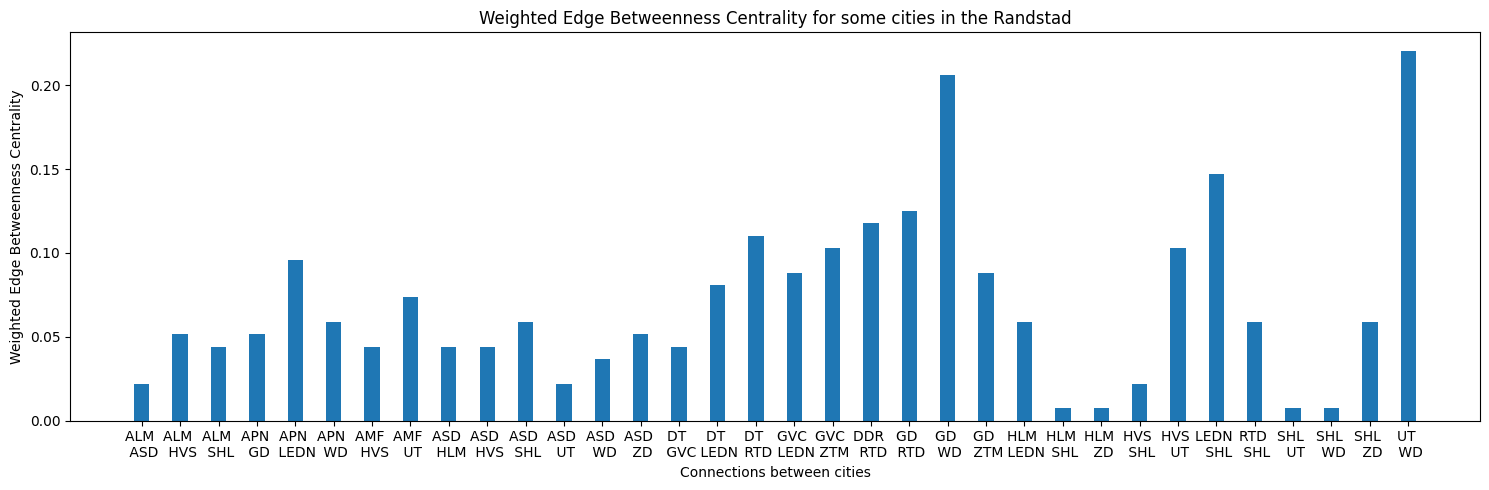

In [5]:
# Helper function for parsing the edge labels
def ppEdges (l):
    rl = []
    for i in range(len(l)):
        rl.append(str(l[i][0]) + ' \n ' + str(l[i][1]))
    return rl

# Plot the values in a bar chart
plt.figure(figsize=(15, 5))
plt.bar(range(len(edge_betweenness_weighted)), edge_betweenness_weighted.values(), width=0.4)
plt.xticks(range(len(edge_betweenness_weighted)), ppEdges(list(edge_betweenness_weighted.keys())))
plt.title("Weighted Edge Betweenness Centrality for some cities in the Randstad")
plt.xlabel("Connections between cities")
plt.ylabel("Weighted Edge Betweenness Centrality")
plt.tight_layout()

ROBUSTNESS ANALYSIS: Top-3 corridor disruption (weight multiplier = 2.0)
Connectivity preserved? Yes

Top critical corridors by weighted edge betweenness (before disruption):
   u   v  weighted_edge_betweenness  weight
  UT  WD                     0.2206  8.7411
  GD  WD                     0.2059  8.8859
LEDN SHL                     0.1471 14.7996

Modified corridors (weights inflated):
  UT <-> WD | EBC=0.2206 | weight: 8.74 -> 17.48
  GD <-> WD | EBC=0.2059 | weight: 8.89 -> 17.77
  LEDN <-> SHL | EBC=0.1471 | weight: 14.80 -> 29.60

Node-level comparison (baseline vs disrupted):
Node  Closeness_base  Closeness_disrupted  Delta_closeness  Pct_closeness_change  Betweenness_base  Betweenness_disrupted  Delta_betweenness  Pct_betweenness_change  Accessibility_base  Accessibility_disrupted  Delta_accessibility  Pct_accessibility_change  Closeness_rank_base  Closeness_rank_disrupted  Closeness_rank_shift  Accessibility_rank_base  Accessibility_rank_disrupted  Accessibility_rank_shift
  W

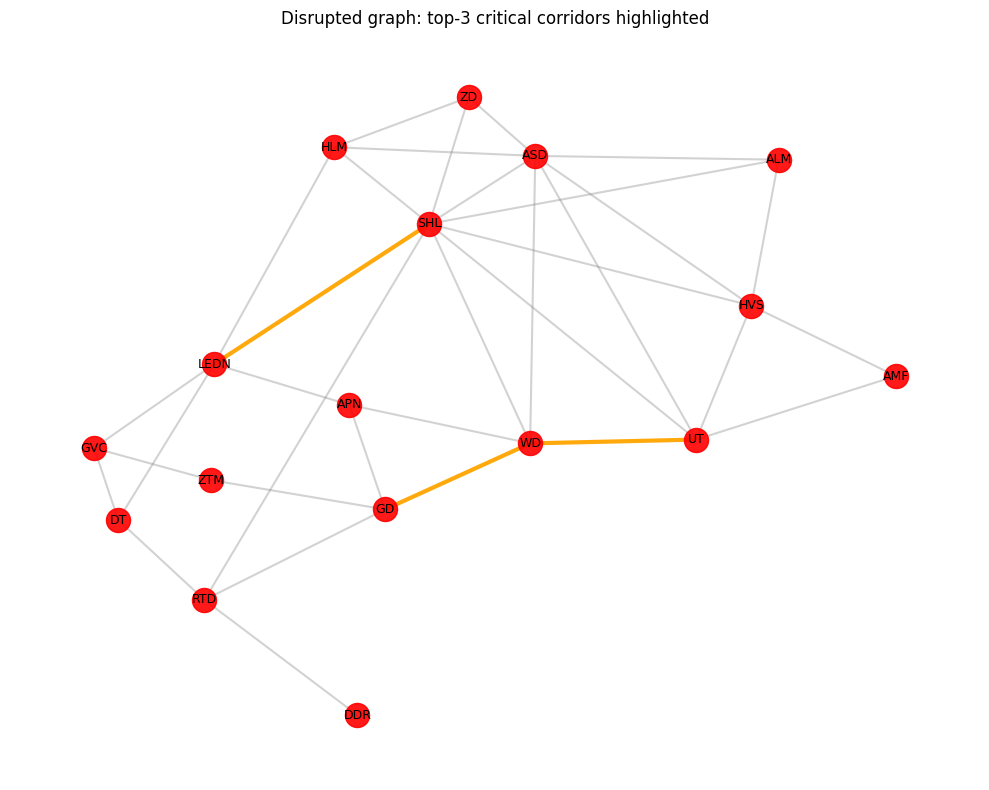

In [12]:
# =============================================================
# Part 3 - Robustness Analysis via Edge Disruption
# =============================================================


def compute_weighted_node_metrics(graph):
    """Return weighted closeness, weighted betweenness, and accessibility."""
    closeness = nx.closeness_centrality(graph, distance="weight")
    betweenness = nx.betweenness_centrality(graph, weight="weight", normalized=True)

    accessibility = {}
    for node in graph.nodes():
        path_lengths = nx.single_source_dijkstra_path_length(graph, node, weight="weight")
        other_lengths = [dist for target, dist in path_lengths.items() if target != node]
        accessibility[node] = np.mean(other_lengths) if other_lengths else float("inf")

    return closeness, betweenness, accessibility


def build_metrics_table(graph, closeness, betweenness, accessibility):
    """Create a node-level metrics table and rankings."""
    table = pd.DataFrame({
        "Node": list(graph.nodes()),
        "Closeness": [closeness[n] for n in graph.nodes()],
        "Betweenness": [betweenness[n] for n in graph.nodes()],
        "Accessibility": [accessibility[n] for n in graph.nodes()]
    })

    # Higher closeness is better; lower accessibility is better.
    table["Closeness_rank"] = table["Closeness"].rank(ascending=False, method="min").astype(int)
    table["Accessibility_rank"] = table["Accessibility"].rank(ascending=True, method="min").astype(int)
    return table


def get_critical_edges_by_weighted_ebc(graph):
    """Compute and rank weighted edge betweenness centrality for all edges."""
    edge_bc = nx.edge_betweenness_centrality(graph, weight="weight", normalized=True)
    ranked = (
        pd.DataFrame([
            {
                "u": u,
                "v": v,
                "edge": (u, v),
                "weighted_edge_betweenness": bc,
                "weight": graph[u][v]["weight"]
            }
            for (u, v), bc in edge_bc.items()
        ])
        .sort_values("weighted_edge_betweenness", ascending=False)
        .reset_index(drop=True)
    )
    return ranked


def apply_edge_disruption(base_graph, ranked_edges_df, k=5, factor=2.0):
    """Copy graph and inflate top-k critical corridor weights by a disruption factor."""
    disrupted = base_graph.copy()
    selected = ranked_edges_df.head(k).copy()

    modified_edges = []
    for _, row in selected.iterrows():
        u, v = row["u"], row["v"]
        old_weight = disrupted[u][v]["weight"]
        new_weight = old_weight * factor
        disrupted[u][v]["weight"] = new_weight

        modified_edges.append({
            "edge": (u, v),
            "edge_bc": row["weighted_edge_betweenness"],
            "old_weight": old_weight,
            "new_weight": new_weight
        })

    return disrupted, selected, modified_edges


# -------------------------------------------------------------
# Scenario parameters (as specified)
# -------------------------------------------------------------
k = 3
factor = 2.0

# 1-2) Compute weighted edge betweenness and rank critical corridors
ranked_edges_df = get_critical_edges_by_weighted_ebc(G_red)

# 3-4) Select top-k edges and increase impedance (weights)
G_disrupted, selected_critical_edges, modified_edges = apply_edge_disruption(
    G_red,
    ranked_edges_df,
    k=k,
    factor=factor
)

# Verify network remains connected after disruption (weights changed, topology preserved)
connectivity_preserved = nx.is_connected(G_red) == nx.is_connected(G_disrupted)

# Baseline metrics
base_closeness, base_betweenness, base_accessibility = compute_weighted_node_metrics(G_red)
baseline_table = build_metrics_table(G_red, base_closeness, base_betweenness, base_accessibility)

# Disrupted metrics
dis_closeness, dis_betweenness, dis_accessibility = compute_weighted_node_metrics(G_disrupted)
disrupted_table = build_metrics_table(G_disrupted, dis_closeness, dis_betweenness, dis_accessibility)

# Build comparison table
comparison_df = baseline_table.rename(columns={
    "Closeness": "Closeness_base",
    "Betweenness": "Betweenness_base",
    "Accessibility": "Accessibility_base",
    "Closeness_rank": "Closeness_rank_base",
    "Accessibility_rank": "Accessibility_rank_base"
}).merge(
    disrupted_table.rename(columns={
        "Closeness": "Closeness_disrupted",
        "Betweenness": "Betweenness_disrupted",
        "Accessibility": "Accessibility_disrupted",
        "Closeness_rank": "Closeness_rank_disrupted",
        "Accessibility_rank": "Accessibility_rank_disrupted"
    }),
    on="Node",
    how="inner"
)

# Absolute and percentage changes
comparison_df["Delta_closeness"] = comparison_df["Closeness_disrupted"] - comparison_df["Closeness_base"]
comparison_df["Delta_betweenness"] = comparison_df["Betweenness_disrupted"] - comparison_df["Betweenness_base"]
comparison_df["Delta_accessibility"] = comparison_df["Accessibility_disrupted"] - comparison_df["Accessibility_base"]

comparison_df["Pct_closeness_change"] = np.where(
    comparison_df["Closeness_base"] != 0,
    100 * comparison_df["Delta_closeness"] / comparison_df["Closeness_base"],
    np.nan
)
comparison_df["Pct_betweenness_change"] = np.where(
    comparison_df["Betweenness_base"] != 0,
    100 * comparison_df["Delta_betweenness"] / comparison_df["Betweenness_base"],
    np.nan
)
comparison_df["Pct_accessibility_change"] = np.where(
    comparison_df["Accessibility_base"] != 0,
    100 * comparison_df["Delta_accessibility"] / comparison_df["Accessibility_base"],
    np.nan
)

# Ranking shifts (negative means ranking improved)
comparison_df["Closeness_rank_shift"] = (
    comparison_df["Closeness_rank_disrupted"] - comparison_df["Closeness_rank_base"]
)
comparison_df["Accessibility_rank_shift"] = (
    comparison_df["Accessibility_rank_disrupted"] - comparison_df["Accessibility_rank_base"]
)

comparison_df = comparison_df.sort_values("Closeness_rank_base").reset_index(drop=True)

print("=" * 84)
print(f"ROBUSTNESS ANALYSIS: Top-{k} corridor disruption (weight multiplier = {factor})")
print("=" * 84)
print(f"Connectivity preserved? {'Yes' if connectivity_preserved else 'No'}")

print("\nTop critical corridors by weighted edge betweenness (before disruption):")
print(
    ranked_edges_df[["u", "v", "weighted_edge_betweenness", "weight"]]
    .head(k)
    .round(4)
    .to_string(index=False)
)

print("\nModified corridors (weights inflated):")
for m in modified_edges:
    print(
        f"  {m['edge'][0]} <-> {m['edge'][1]} | "
        f"EBC={m['edge_bc']:.4f} | "
        f"weight: {m['old_weight']:.2f} -> {m['new_weight']:.2f}"
    )

print("\nNode-level comparison (baseline vs disrupted):")
display_cols = [
    "Node",
    "Closeness_base", "Closeness_disrupted", "Delta_closeness", "Pct_closeness_change",
    "Betweenness_base", "Betweenness_disrupted", "Delta_betweenness", "Pct_betweenness_change",
    "Accessibility_base", "Accessibility_disrupted", "Delta_accessibility", "Pct_accessibility_change",
    "Closeness_rank_base", "Closeness_rank_disrupted", "Closeness_rank_shift",
    "Accessibility_rank_base", "Accessibility_rank_disrupted", "Accessibility_rank_shift"
]
print(comparison_df[display_cols].round(4).to_string(index=False))

# Candidate hubs: top N by baseline closeness
top_n = min(5, len(comparison_df))
candidate_hubs = comparison_df.nsmallest(top_n, "Closeness_rank_base")
print("\nCandidate hubs (top by baseline closeness) and rank changes:")
print(
    candidate_hubs[[
        "Node",
        "Closeness_rank_base", "Closeness_rank_disrupted", "Closeness_rank_shift",
        "Accessibility_rank_base", "Accessibility_rank_disrupted", "Accessibility_rank_shift"
    ]].to_string(index=False)
)

best_hub_base = comparison_df.loc[comparison_df["Closeness_rank_base"].idxmin(), "Node"]
best_hub_dis = comparison_df.loc[comparison_df["Closeness_rank_disrupted"].idxmin(), "Node"]
hub_stable = best_hub_base == best_hub_dis

print("\nBest hub stability check (closeness ranking):")
print(f"  Baseline best hub:  {best_hub_base}")
print(f"  Disrupted best hub: {best_hub_dis}")
print(f"  Stable after disruption? {'Yes' if hub_stable else 'No'}")

# Optional visualization: highlight disrupted edges
if "pos" not in globals():
    pos = {
        node: (data["lon"], data["lat"])
        for node, data in G_red.nodes(data=True)
    }

highlight_edges = [m["edge"] for m in modified_edges]
normal_edges = [
    e for e in G_disrupted.edges()
    if e not in highlight_edges and (e[1], e[0]) not in highlight_edges
]

plt.figure(figsize=(10, 8))
nx.draw_networkx_nodes(G_disrupted, pos, node_color="red", node_size=300, alpha=0.9)
nx.draw_networkx_labels(G_disrupted, pos, font_size=9)
nx.draw_networkx_edges(
    G_disrupted, pos, edgelist=normal_edges, alpha=0.35, width=1.5, edge_color="gray"
)
nx.draw_networkx_edges(
    G_disrupted, pos, edgelist=highlight_edges, alpha=0.95, width=3.0, edge_color="orange"
)
plt.title(f"Disrupted graph: top-{k} critical corridors highlighted")
plt.axis("off")
plt.tight_layout()
plt.show()

# Keep key outputs available for later cells
part3_ranked_edges_df = ranked_edges_df
part3_selected_critical_edges = selected_critical_edges
part3_modified_edges = modified_edges
part3_comparison_df = comparison_df
part3_G_disrupted = G_disrupted
